In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("glenmore_traffic.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70080 entries, 0 to 70079
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   DIRECTION   70080 non-null  object
 1   STUDY_DATE  70080 non-null  object
 2   VOLUME      70080 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ MB


In [3]:
# convert the study date to datetime for plotting
df["STUDY_DATE"] = pd.to_datetime(df["STUDY_DATE"], format=r"%m/%d/%Y %I:%M:%S %p")

(np.float64(19358.0), np.float64(19359.0))

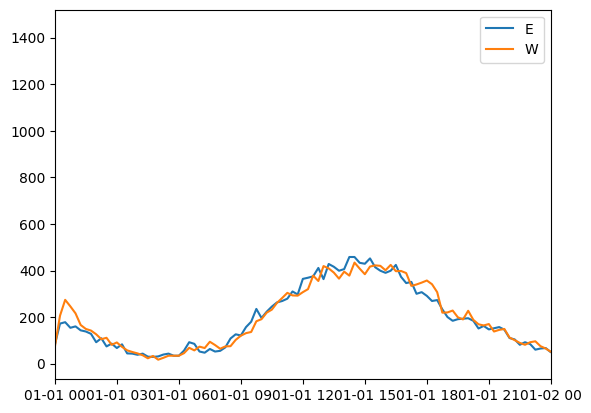

In [15]:
for dir in ["E", "W"]:
    this_dir = df[df["DIRECTION"] == dir]
    plt.plot(this_dir["STUDY_DATE"], this_dir["VOLUME"], label=dir)

plt.legend()
# zoom in so we can see a bit more detail
plt.xlim(pd.to_datetime(["2023-01-01", "2023-01-2"]))

In [5]:
# pull the date/month/time info out of the datetime object
def extract_date_features(df):
    df["DAY_OF_WEEK"] = df["STUDY_DATE"].dt.weekday  # coded 0 to 6
    df["DAY_OF_MONTH"] = df["STUDY_DATE"].dt.day
    df["MONTH"] = df["STUDY_DATE"].dt.month
    df["TIME_HOUR"] = df["STUDY_DATE"].dt.hour
    df["TIME_MINUTES"] = df["STUDY_DATE"].dt.minute

    return df.drop(columns="STUDY_DATE")


<Axes: xlabel='DAY_OF_WEEK,DIRECTION'>

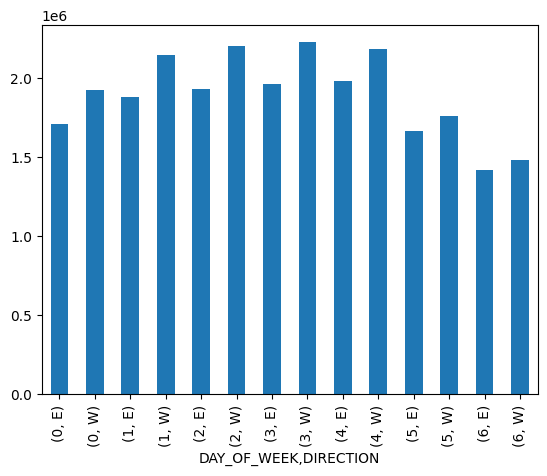

In [7]:
# Maybe the day of the week is important?
date_df = extract_date_features(df)
date_df.groupby(["DAY_OF_WEEK", "DIRECTION"])["VOLUME"].sum().plot.bar()

In [ ]:
# try a super basic model
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

# BIG MISTAKE! Can't randomly split time series data
# train, val = train_test_split(df, test_size=0.2)
threshold = int(len(df) * 0.8)
train = df.iloc[:threshold].copy()
val = df.iloc[threshold:].copy()

model = RandomForestRegressor()

pipeline = make_pipeline (
        FunctionTransformer(extract_date_features),
        make_column_transformer(
            (OneHotEncoder(sparse_output=False, drop="if_binary"), ["DIRECTION"]),
            ("passthrough", ["DAY_OF_WEEK", "MONTH", "TIME_HOUR"])
        ),
        model,
).set_output(transform="pandas")

pipeline.fit(train, train["VOLUME"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('functiontransformer', ...), ('columntransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function ext...002169C25D8A0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional ke

In [22]:
pipeline[:-1].transform(train)

,onehotencoder__DIRECTION_W,passthrough__DAY_OF_WEEK,passthrough__MONTH,passthrough__TIME_HOUR
0,1.0,6,1,0
1,0.0,6,1,0
2,1.0,6,1,0
3,0.0,6,1,0
4,1.0,6,1,0
...,...,...,...,...
56059,0.0,3,10,23
56060,1.0,3,10,23
56061,0.0,3,10,23
56062,1.0,3,10,23


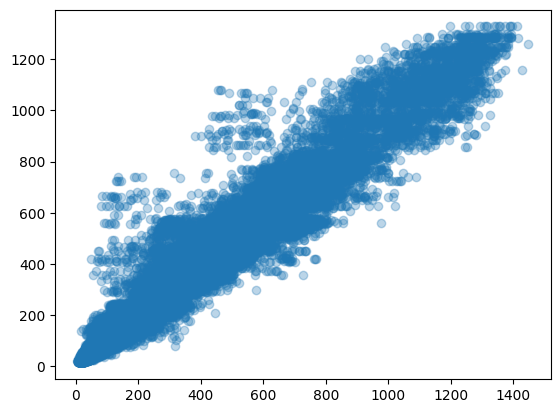

In [23]:
plt.scatter(train["VOLUME"], pipeline.predict(train), alpha=0.3)

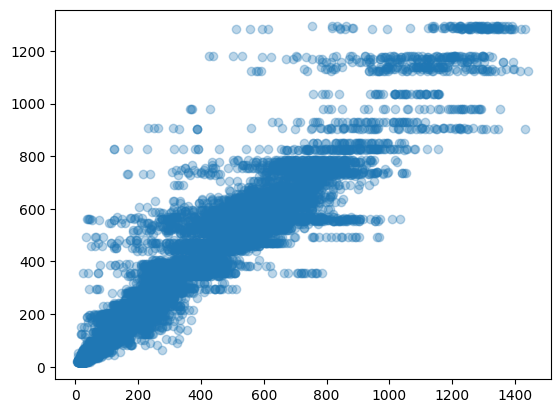

In [24]:
# test on validation data
y_est = pipeline.predict(val)
plt.scatter(val["VOLUME"], y_est, alpha=0.3)

In [25]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(val["VOLUME"], y_est))

53.902873592291115
